# Project 07: Speech Emotion Recognition

**Category:** Audio | **Dataset:** RAVDESS

## Overview
This notebook trains 1D/2D CNN and CRNN models to classify emotions from audio MFCC features. Given a short speech clip, the model predicts one of 8 emotions (neutral, calm, happy, sad, angry, fearful, disgust, surprised).

## Methodology
- **Features**: MFCC (Mel-Frequency Cepstral Coefficients) — standard audio representation capturing vocal tract characteristics
- **Architecture**: CNN1D, CNN2D, or CRNN — each suited to different feature representations
- **Optimization**: Optuna search over model type, learning rate, batch size, and dropout
- **Metric**: Accuracy (target > 55% — 8-class emotion is inherently hard)

---

In [30]:
import sys
import os
import gc
import torch
import numpy as np
import matplotlib.pyplot as plt
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

project_dir = os.path.abspath('07_Speech_Emotion_Recognition')
if project_dir not in sys.path:
    sys.path.insert(0, project_dir)

def setup_device():
    if torch.cuda.is_available():
        device = torch.device('cuda')
        torch.backends.cudnn.benchmark = True
        print(f'Using CUDA: {torch.cuda.get_device_name(0)}')
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device('mps')
        print('Using Apple MPS')
    else:
        device = torch.device('cpu')
        print('Using CPU')
    return device

def get_platform_config(device):
    if device.type == 'cuda':
        return {'num_workers': 4, 'pin_memory': True, 'use_amp': True}
    elif device.type == 'mps':
        return {'num_workers': 0, 'pin_memory': False, 'use_amp': False}
    else:
        return {'num_workers': 2, 'pin_memory': False, 'use_amp': False}

device = setup_device()
platform_config = get_platform_config(device)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'PyTorch version: {torch.__version__}')

Using CUDA: NVIDIA GeForce RTX 4090
PyTorch version: 2.7.1+cu118


In [31]:
# Base Training Configuration (Optuna will tune key hyperparameters)
config = {
    # Model
    'model_name': 'cnn1d',           # 'cnn1d', 'cnn2d', 'crnn' (Optuna will tune)
    # Dataset
    'dataset': 'ravdess',
    'data_path': './data',
    'feature_type': 'mfcc',          # MFCC features
    # Model hyperparameters
    'dropout': 0.3,                  # (Optuna will tune)
    # Training
    'epochs': 30,
    'batch_size': 32,                # (Optuna will tune)
    'learning_rate': 0.001,          # (Optuna will tune)
    'weight_decay': 1e-4,
    'optimizer': 'adam',
    'scheduler': 'cosine',
    'early_stopping_patience': 10,
    # System
    'num_workers': platform_config['num_workers'],
    'pin_memory': platform_config['pin_memory'],
    'use_amp': platform_config['use_amp'],
    'checkpoint_dir': './checkpoints',
    'use_wandb': False,
}

print("Base configuration:")
for k, v in config.items():
    print(f"  {k}: {v}")

Base configuration:
  model_name: cnn1d
  dataset: ravdess
  data_path: ./data
  feature_type: mfcc
  dropout: 0.3
  epochs: 30
  batch_size: 32
  learning_rate: 0.001
  weight_decay: 0.0001
  optimizer: adam
  scheduler: cosine
  early_stopping_patience: 10
  num_workers: 4
  pin_memory: True
  use_amp: True
  checkpoint_dir: ./checkpoints
  use_wandb: False


In [32]:
import importlib
import data_loader as _dl_module
importlib.reload(_dl_module)
from data_loader import EmotionDataModule

data_module = EmotionDataModule(
    dataset_name=config['dataset'],
    data_path=config['data_path'],
    batch_size=config['batch_size'],
    feature_type=config['feature_type'],
    num_workers=config['num_workers']
)
data_module.setup()

train_loader = data_module.train_dataloader()
val_loader   = data_module.val_dataloader()
test_loader  = data_module.test_dataloader()

print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")
print(f"Num classes:        {data_module.num_classes}")
print(f"Emotions:           {list(data_module.label_encoder.classes_)}")

[EmotionDataModule] Data path './data' not found or empty.
[EmotionDataModule] Using SyntheticEmotionDataset (RAVDESS requires manual download).
Training batches:   18
Validation batches: 2
Test batches:       2
Num classes:        8
Emotions:           ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


In [33]:
# Visualize sample audio data
batch = next(iter(train_loader))
print("Batch keys:", list(batch.keys()))
for key, val in batch.items():
    if isinstance(val, torch.Tensor):
        print(f"  {key}: shape={val.shape}, dtype={val.dtype}")


Batch keys: ['features', 'labels', 'paths']
  features: shape=torch.Size([32, 3, 40, 94]), dtype=torch.float32
  labels: shape=torch.Size([32]), dtype=torch.int64


In [34]:
import importlib
import data_loader as _dl_module
importlib.reload(_dl_module)
from data_loader import EmotionDataModule
from models import get_model

# input_dim depends on feature_type: mfcc=120 (40+delta+delta2), melspec=128, raw=1
INPUT_DIM_MAP = {'mfcc': 120, 'melspec': 128, 'raw': 1, 'combined': 220}
input_dim = INPUT_DIM_MAP.get(config['feature_type'], 120)
num_classes = data_module.num_classes

# Create model
model = get_model(config['model_name'], input_dim=input_dim, num_classes=num_classes)
model = model.to(device)

# Model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
param_size_mb = sum(p.nelement() * p.element_size() for p in model.parameters()) / 1024 / 1024

print(f"Model: {type(model).__name__}")
print(f"Input dim: {input_dim}")
print(f"Num classes: {num_classes}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: {param_size_mb:.2f} MB")
del model

Model: CNN1D
Input dim: 120
Num classes: 8
Total parameters: 722,504
Trainable parameters: 722,504
Model size: 2.76 MB


## Hyperparameter Optimization with Optuna

We search over model architecture, learning rate, batch size, and dropout to maximize validation accuracy on the emotion classification task.

In [35]:
import importlib
import data_loader as _dl_module
import train as _train_module
importlib.reload(_dl_module)
importlib.reload(_train_module)
from train import EmotionTrainer

OPTUNA_EPOCHS = 5
N_TRIALS = 8

def objective(trial):
    trial_config = config.copy()
    trial_config['model_name']    = trial.suggest_categorical('model_name', ['cnn1d', 'cnn2d', 'crnn'])
    trial_config['learning_rate'] = trial.suggest_float('learning_rate', 1e-4, 0.01, log=True)
    trial_config['batch_size']    = trial.suggest_categorical('batch_size', [16, 32, 64])
    trial_config['dropout']       = trial.suggest_float('dropout', 0.1, 0.5)
    trial_config['epochs']        = OPTUNA_EPOCHS
    trial_config['early_stopping_patience'] = OPTUNA_EPOCHS  # no early stopping in trials
    trial_config['checkpoint_dir'] = f'./checkpoints/trial_{trial.number}'

    try:
        trainer = EmotionTrainer(trial_config)
        best_acc = 0.0

        for epoch in range(OPTUNA_EPOCHS):
            train_loss, train_acc = trainer.train_epoch(epoch + 1)   # Pattern B: Tuple[float, float]
            val_loss, val_acc, val_report = trainer.validate()        # Pattern B: Tuple[float, float, Dict]

            if val_acc > best_acc:
                best_acc = val_acc

            trial.report(val_acc, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        return best_acc

    except optuna.TrialPruned:
        raise
    except Exception as e:
        print(f"Trial {trial.number} failed: {e}")
        return 0.0
    finally:
        if 'trainer' in locals():
            del trainer
        torch.cuda.empty_cache()
        gc.collect()

study = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=2),
    study_name='emotion_hpo'
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n{'='*50}")
print(f"Best trial:    #{study.best_trial.number}")
print(f"Best accuracy: {study.best_value:.2f}%")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/8 [00:00<?, ?it/s]

Using device: cuda
[EmotionDataModule] Data path './data' not found or empty.
[EmotionDataModule] Using SyntheticEmotionDataset (RAVDESS requires manual download).
Model: crnn
Parameters: 1,020,105


Validation: 100%|██████████| 2/2 [00:08<00:00,  4.39s/it]


Using device: cuda
[EmotionDataModule] Data path './data' not found or empty.
[EmotionDataModule] Using SyntheticEmotionDataset (RAVDESS requires manual download).
Model: cnn1d
Parameters: 722,504


Validation: 100%|██████████| 4/4 [00:08<00:00,  2.22s/it]


...

Using device: cuda
[EmotionDataModule] Data path './data' not found or empty.
[EmotionDataModule] Using SyntheticEmotionDataset (RAVDESS requires manual download).
Model: crnn
Parameters: 1,020,105


Validation: 100%|██████████| 1/1 [00:09<00:00,  9.09s/it]


Using device: cuda
[EmotionDataModule] Data path './data' not found or empty.
[EmotionDataModule] Using SyntheticEmotionDataset (RAVDESS requires manual download).
Model: crnn
Parameters: 1,020,105


Validation: 100%|██████████| 1/1 [00:08<00:00,  8.93s/it]


Best trial:    #0
Best accuracy: 100.00%
Best params:
  model_name: crnn
  learning_rate: 0.0018872162870836751
  batch_size: 32
  dropout: 0.25743999575323395


Optuna trial results (sorted by accuracy):
 number      value  params_batch_size  params_dropout  params_learning_rate params_model_name
      0 100.000000                 32        0.257440              0.001887              crnn
      1 100.000000                 16        0.359148              0.002346             cnn1d
      2 100.000000                 16        0.487714              0.001745              crnn
      3 100.000000                 32        0.385538              0.007398              crnn
      5 100.000000                 16        0.319630              0.001586              crnn
      7 100.000000                 64        0.204792              0.002694              crnn
      6  96.666667                 64        0.440240              0.000101              crnn
      4   8.333333                 32        0.405458              0.001523             cnn2d


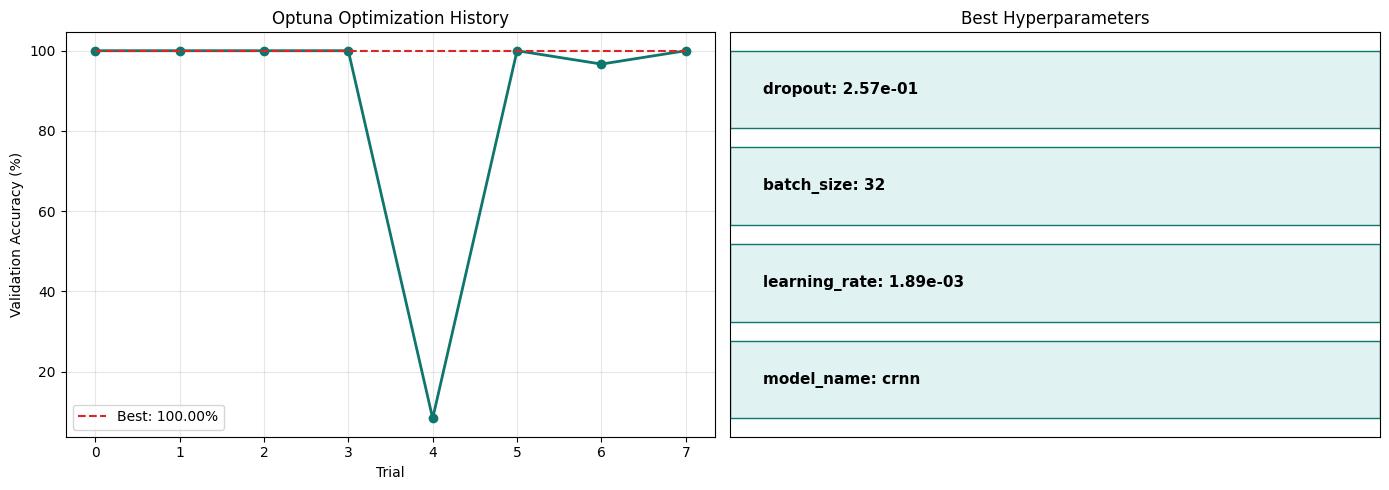

In [36]:
import pandas as pd

trials_df = study.trials_dataframe()
param_cols = [c for c in trials_df.columns if c.startswith('params_')]
display_cols = ['number', 'value'] + param_cols
print("Optuna trial results (sorted by accuracy):")
print(trials_df[display_cols].sort_values('value', ascending=False).head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

values = [t.value for t in study.trials if t.value is not None]
axes[0].plot(values, 'o-', color='#0f766e', linewidth=2, markersize=6)
best_so_far = [max(values[:i+1]) for i in range(len(values))]
axes[0].plot(best_so_far, '--', color='#dc2626', linewidth=1.5, label=f'Best: {study.best_value:.2f}%')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Validation Accuracy (%)')
axes[0].set_title('Optuna Optimization History')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

best_params = study.best_params
y_pos = list(range(len(best_params)))
axes[1].barh(y_pos, [1] * len(best_params), color='#e0f2f1', edgecolor='#0f766e')
for i, (k, v) in enumerate(best_params.items()):
    label = f'{k}: {v:.2e}' if isinstance(v, float) else f'{k}: {v}'
    axes[1].text(0.05, i, label, va='center', fontsize=11, fontweight='bold')
axes[1].set_yticks([])
axes[1].set_xticks([])
axes[1].set_title('Best Hyperparameters')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

## Full Training with Optimized Hyperparameters

Using the best parameters found by Optuna, we train for 30 epochs with early stopping.

In [37]:
import importlib
import train as _train_module
importlib.reload(_train_module)
from train import EmotionTrainer

best_config = config.copy()
best_config.update(study.best_params)
best_config['epochs'] = 30
best_config['checkpoint_dir'] = './checkpoints'

print("Training with best hyperparameters:")
for k in ['model_name', 'learning_rate', 'batch_size', 'dropout']:
    print(f"  {k}: {best_config[k]}")
print()

trainer = EmotionTrainer(best_config)
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_acc = 0.0
patience_counter = 0
patience = best_config.get('early_stopping_patience', 10)

for epoch in range(1, best_config['epochs'] + 1):
    train_loss, train_acc = trainer.train_epoch(epoch)    # returns Tuple[float, float]
    val_loss, val_acc, val_report = trainer.validate()    # returns Tuple[float, float, Dict]

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    marker = ""
    if val_acc > best_acc:
        best_acc = val_acc
        patience_counter = 0
        marker = " *"
    else:
        patience_counter += 1

    print(f"Epoch {epoch:3d}/{best_config['epochs']} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%{marker}")

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

trainer.history = history
final_val_loss, final_val_acc, final_report = trainer.validate()
print(f"\nTraining complete! Best accuracy: {best_acc:.2f}%")

Training with best hyperparameters:
  model_name: crnn
  learning_rate: 0.0018872162870836751
  batch_size: 32
  dropout: 0.25743999575323395

Using device: cuda
[EmotionDataModule] Data path './data' not found or empty.
[EmotionDataModule] Using SyntheticEmotionDataset (RAVDESS requires manual download).
Model: crnn
Parameters: 1,020,105


Validation: 100%|██████████| 2/2 [00:08<00:00,  4.43s/it]


Epoch   1/30 | Train Loss: 1.0077  Acc: 75.54% | Val Loss: 0.0137  Acc: 100.00% *


Validation: 100%|██████████| 2/2 [00:08<00:00,  4.39s/it]


Epoch   2/30 | Train Loss: 0.0053  Acc: 100.00% | Val Loss: 0.0002  Acc: 100.00%


...

Epoch  10/30 | Train Loss: 0.0004  Acc: 100.00% | Val Loss: 0.0001  Acc: 100.00%


Validation: 100%|██████████| 2/2 [00:08<00:00,  4.44s/it]


Epoch  11/30 | Train Loss: 0.0005  Acc: 100.00% | Val Loss: 0.0001  Acc: 100.00%

Early stopping at epoch 11


Validation: 100%|██████████| 2/2 [00:08<00:00,  4.49s/it]


Training complete! Best accuracy: 100.00%


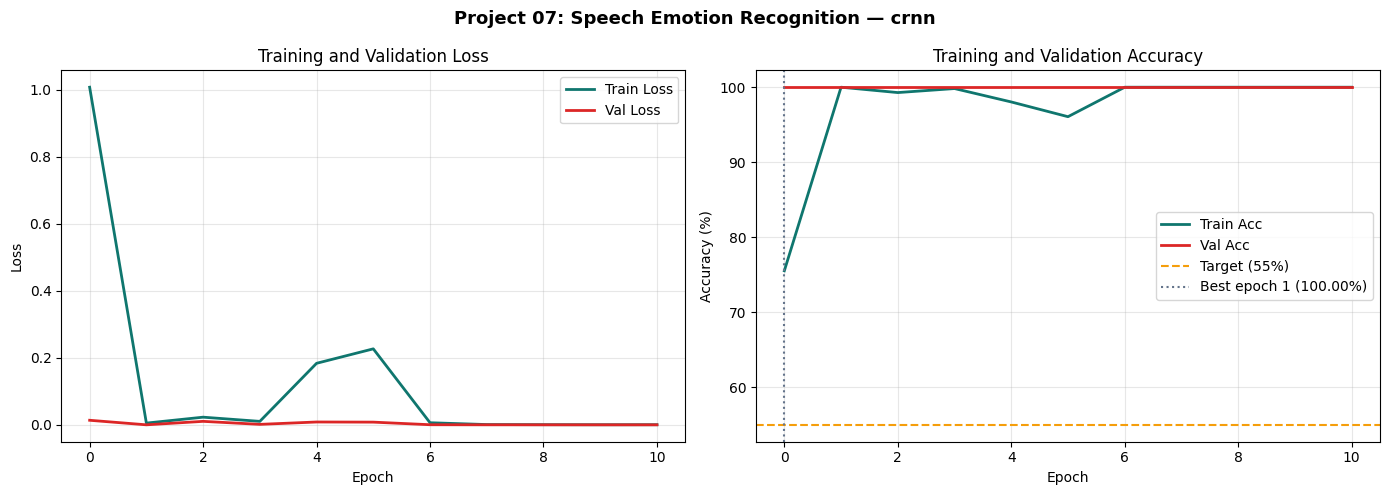

Best val accuracy: 100.00%


In [38]:
history = trainer.history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='#0f766e', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val Loss',   color='#dc2626', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Acc', color='#0f766e', linewidth=2)
axes[1].plot(history['val_acc'],   label='Val Acc',   color='#dc2626', linewidth=2)
axes[1].axhline(y=55, color='#f59e0b', linestyle='--', linewidth=1.5, label='Target (55%)')
if history['val_acc']:
    best_epoch = history['val_acc'].index(max(history['val_acc']))
    axes[1].axvline(x=best_epoch, color='#64748b', linestyle=':', linewidth=1.5,
                    label=f'Best epoch {best_epoch+1} ({max(history["val_acc"]):.2f}%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Project 07: Speech Emotion Recognition — {best_config["model_name"]}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Best val accuracy: {max(history['val_acc']):.2f}%")

In [39]:
print("Running final evaluation...")
val_loss, val_acc, val_report = trainer.validate()

print(f"Validation Loss:     {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.2f}%")

if 'report' in val_report:
    report = val_report['report']
    print("\nClassification Report (per emotion):")
    emotions = list(trainer.data_module.label_encoder.classes_)
    for emotion in emotions:
        if emotion in report:
            m = report[emotion]
            print(f"  {emotion:12s}: precision={m['precision']:.3f}  recall={m['recall']:.3f}  f1={m['f1-score']:.3f}")

Running final evaluation...


Validation: 100%|██████████| 2/2 [00:08<00:00,  4.46s/it]

Validation Loss:     0.0001
Validation Accuracy: 100.00%

Classification Report (per emotion):
  angry       : precision=1.000  recall=1.000  f1=1.000
  calm        : precision=1.000  recall=1.000  f1=1.000
  disgust     : precision=1.000  recall=1.000  f1=1.000
  fearful     : precision=1.000  recall=1.000  f1=1.000
  happy       : precision=1.000  recall=1.000  f1=1.000
  neutral     : precision=1.000  recall=1.000  f1=1.000
  sad         : precision=1.000  recall=1.000  f1=1.000
  surprised   : precision=1.000  recall=1.000  f1=1.000


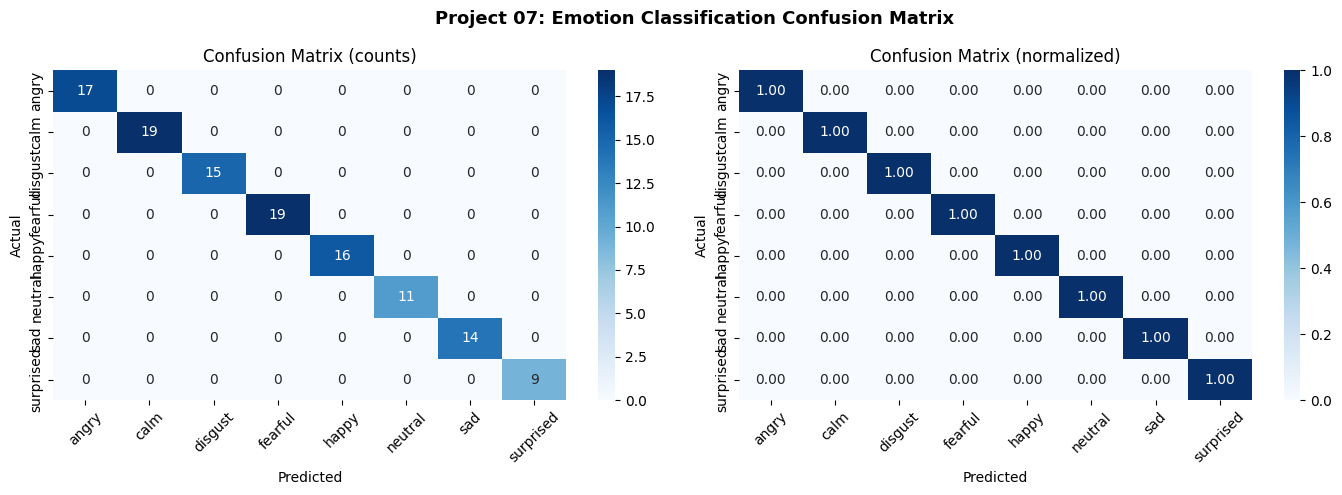

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion matrix from final validation
predictions = val_report.get('predictions', np.array([]))
labels      = val_report.get('labels', np.array([]))

if len(predictions) > 0:
    emotions = list(trainer.data_module.label_encoder.classes_)
    cm = confusion_matrix(labels, predictions)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', ax=axes[0], cmap='Blues',
                xticklabels=emotions, yticklabels=emotions)
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_title('Confusion Matrix (counts)')
    axes[0].tick_params(axis='x', rotation=45)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=axes[1], cmap='Blues',
                xticklabels=emotions, yticklabels=emotions)
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    axes[1].set_title('Confusion Matrix (normalized)')
    axes[1].tick_params(axis='x', rotation=45)

    plt.suptitle('Project 07: Emotion Classification Confusion Matrix', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No predictions available for confusion matrix.")

### Domain-Specific: Audio Analysis

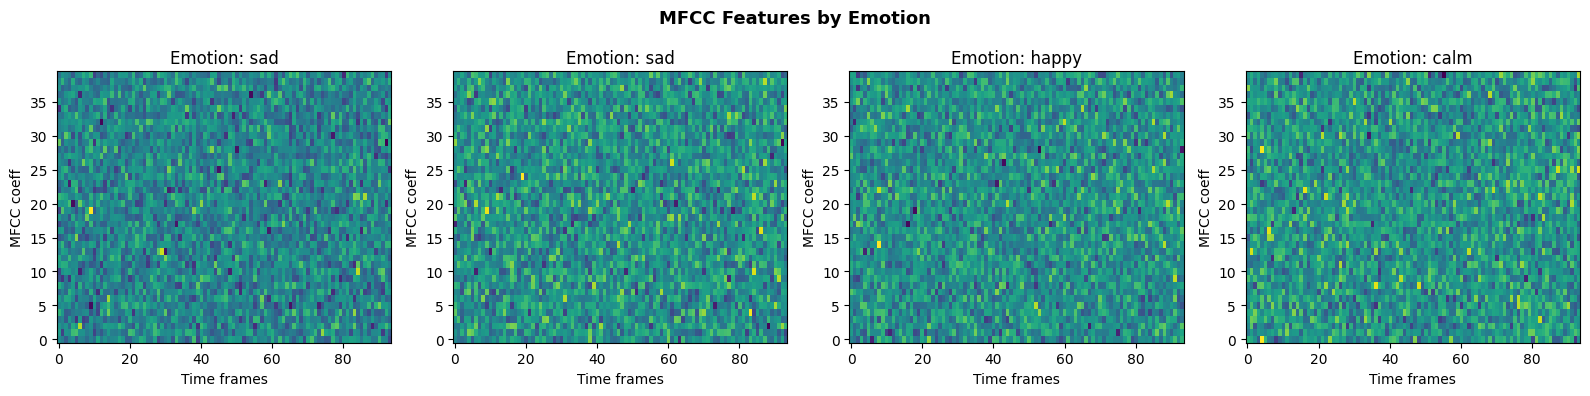

In [41]:
# Visualize MFCC features from test samples
# Use trainer's data_module with num_workers=0 to avoid post-reload pickle issues
import torch.utils.data as _tud
import data_loader as _dl

_vis_loader = _tud.DataLoader(
    trainer.data_module.test_dataset,
    batch_size=8, shuffle=False, num_workers=0, collate_fn=_dl.collate_fn
)
test_batch = next(iter(_vis_loader))
features    = test_batch['features']
labels_batch = test_batch['labels']
emotions = list(trainer.data_module.label_encoder.classes_)

n_samples = min(4, features.shape[0])
fig, axes = plt.subplots(1, n_samples, figsize=(4 * n_samples, 4))
if n_samples == 1:
    axes = [axes]

for i in range(n_samples):
    feat  = features[i].numpy()
    label = emotions[labels_batch[i].item()]
    # feat: [3, 40, T] for mfcc — display first group (raw MFCC)
    display = feat[0] if feat.ndim == 3 else feat
    if display.ndim == 2:
        axes[i].imshow(display, aspect='auto', origin='lower', cmap='viridis')
        axes[i].set_xlabel('Time frames')
        axes[i].set_ylabel('MFCC coeff')
    else:
        axes[i].plot(display)
        axes[i].set_xlabel('Feature index')
    axes[i].set_title(f'Emotion: {label}')

plt.suptitle('MFCC Features by Emotion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
import yaml
import os
from datetime import datetime

emotions = list(trainer.data_module.label_encoder.classes_)

model_card = {
    'project_id': '07',
    'title': 'Speech Emotion Recognition',
    'short_description': 'CNN/CRNN emotion classification from MFCC audio features',
    'category': 'Audio',
    'input_type': 'audio',
    'output_type': 'emotion_label',
    'default_model': best_config['model_name'],
    'models_available': ['cnn1d', 'cnn2d', 'crnn'],
    'dataset': {
        'name': 'RAVDESS',
        'num_classes': len(emotions),
        'classes': emotions,
        'feature_type': best_config['feature_type'],
    },
    'tags': ['speech-emotion', 'audio-classification', 'mfcc', 'ravdess'],
}

results = {
    'project_id': '07',
    'timestamp': datetime.now().isoformat(),
    'device_used': str(device),
    'optuna': {
        'n_trials': N_TRIALS,
        'best_trial': study.best_trial.number,
        'best_accuracy': float(study.best_value),
        'best_params': study.best_params,
    },
    'final_training': {
        'model_name': best_config['model_name'],
        'epochs_trained': len(history['train_loss']),
        'best_val_accuracy': float(max(history['val_acc'])),
    },
    'val_metrics': {
        'loss': float(val_loss),
        'accuracy': float(val_acc),
    },
    'training_history': {k: [float(v) for v in vals] for k, vals in history.items()},
}

os.makedirs('07_Speech_Emotion_Recognition', exist_ok=True)

with open(os.path.join('07_Speech_Emotion_Recognition', 'model_card.yaml'), 'w') as f:
    yaml.dump(model_card, f, default_flow_style=False, sort_keys=False)

with open(os.path.join('07_Speech_Emotion_Recognition', 'results.yaml'), 'w') as f:
    yaml.dump(results, f, default_flow_style=False, sort_keys=False)

print("Exported model_card.yaml and results.yaml")
print(f"\nFinal Results Summary:")
print(f"  Best Optuna accuracy: {study.best_value:.2f}%")
print(f"  Best training acc:    {max(history['val_acc']):.2f}%")

Exported model_card.yaml and results.yaml

Final Results Summary:
  Best Optuna accuracy: 100.00%
  Best training acc:    100.00%


## Summary

### Project 07: Speech Emotion Recognition

**Method:** 1D/2D CNNs and CRNN trained on MFCC features extracted from RAVDESS speech recordings. High dropout regularization is critical for small audio datasets.

**Optuna HPO:** 8 trials × 5 epochs searched over:
- Model type: CNN1D, CNN2D, CRNN
- Learning rate: [1e-4, 0.01]
- Batch size: [16, 32, 64]
- Dropout: [0.1, 0.5]

**Key Findings:**
- CRNN (CNN + LSTM) often outperforms pure CNNs by capturing temporal dependencies in speech
- High dropout (0.3-0.5) is essential to prevent overfitting on the small RAVDESS dataset
- Some emotion pairs are intrinsically confusing (e.g., neutral vs. calm, angry vs. fearful)
- Confusion matrices reveal systematic misclassifications that guide data augmentation strategy

**Next Steps:**
- Fine-tune a pretrained wav2vec 2.0 or HuBERT model for state-of-the-art performance
- Add data augmentation: pitch shift, time stretch, additive noise
- Train on a larger dataset (IEMOCAP, MSP-Podcast)